Dataset shape: (48842, 15)
Missing values converted to NaN.

Target distribution:
target
0    37155
1    11687
Name: count, dtype: int64
---DATA SPLIT---
Training: (34188, 14)
Development: (4885, 14)
Hold-out Test: (9769, 14)

Training Logistic Regression...
Logistic Regression training completed!

Training Decision Tree...
Decision Tree training completed!
HOLD-OUT TEST MODEL COMPARISON
                  Model  Accuracy  Precision  Recall     F1  ROC AUC  PR AUC
      Majority Baseline    0.7607     0.0000  0.0000 0.0000   0.5000  0.2393
Education Rule Baseline    0.7530     0.4844  0.4970 0.4906   0.6653  0.3611
    Logistic Regression    0.8527     0.7431  0.5877 0.6563   0.9039  0.7624
          Decision Tree    0.8183     0.6192  0.6253 0.6223   0.7522  0.4769

Saved: ../outputs/model_comparison.csv
LOGISTIC REGRESSION CONFUSION MATRIX
[[6956  475]
 [ 964 1374]]
DECISION TREE CONFUSION MATRIX
[[6532  899]
 [ 876 1462]]
ERROR TYPE COMPARISON

Logistic Regression:
False Positives: 4

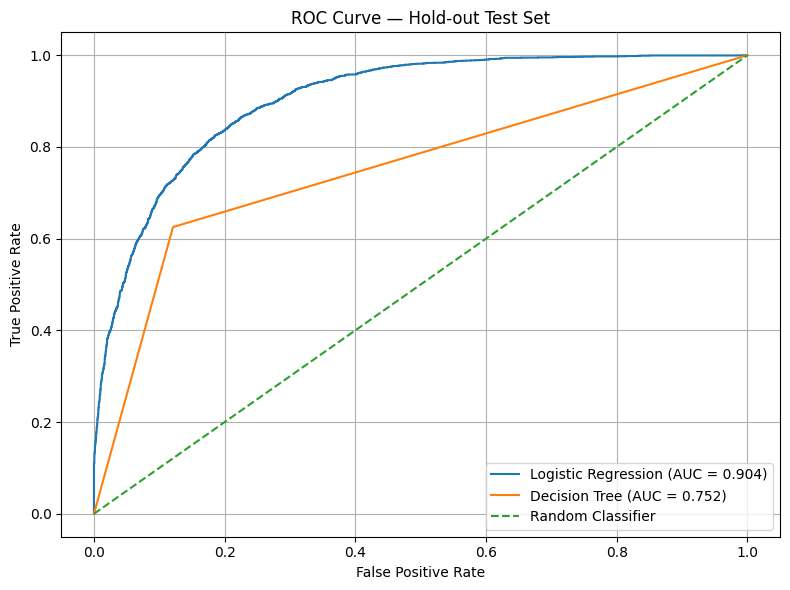

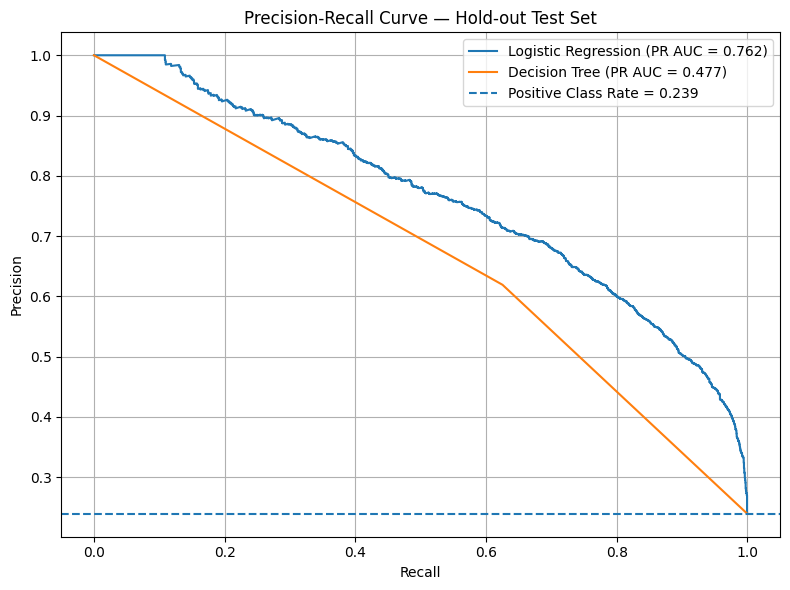

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Create output directory
os.makedirs("../outputs", exist_ok=True)
adult = fetch_openml(
    "adult",
    version=2,
    as_frame=True
)
df = adult.frame.copy()
print("Dataset shape:", df.shape)
df = df.replace("?", np.nan)
print("Missing values converted to NaN.")

df["target"] = df["class"].map({
    "<=50K": 0,
    ">50K": 1
}).astype(int)
print("\nTarget distribution:")
print(df["target"].value_counts())

X = df.drop(
    columns=["class", "target"]
)
y = df["target"]

numeric_features = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)
X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev,
    y_train_dev,
    test_size=0.125,
    random_state=42,
    stratify=y_train_dev
)
print("---DATA SPLIT---")
print("Training:", X_train.shape)
print("Development:", X_dev.shape)
print("Hold-out Test:", X_test.shape)

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                solver="liblinear",
                random_state=42,
                max_iter=1000
            )
        )
    ]
)


decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)


print("\nTraining Logistic Regression...")

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed!")

print("\nTraining Decision Tree...")

decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree training completed!")

logistic_test_predictions = logistic_pipeline.predict(
    X_test
)

tree_test_predictions = decision_tree_pipeline.predict(
    X_test
)



logistic_test_probabilities = (
    logistic_pipeline.predict_proba(X_test)[:, 1]
)

tree_test_probabilities = (
    decision_tree_pipeline.predict_proba(X_test)[:, 1]
)
#  Evaluation function

def evaluate_model(
    y_true,
    y_pred,
    y_probability
):
    
    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        
        "ROC AUC": roc_auc_score(
            y_true,
            y_probability
        ),
        
        "PR AUC": average_precision_score(
            y_true,
            y_probability
        )
    }

#  Evaluate Logistic Regression

logistic_metrics = evaluate_model(
    y_test,
    logistic_test_predictions,
    logistic_test_probabilities
)

# Evaluate Decision Tree

tree_metrics = evaluate_model(
    y_test,
    tree_test_predictions,
    tree_test_probabilities
)

# BASELINE MODELS
# Majority-class baseline
majority_predictions = np.zeros(
    len(y_test),
    dtype=int
)
# Use the training positive rate as the probability score.
positive_rate = y_train.mean()

majority_probabilities = np.full(
    len(y_test),
    positive_rate
)

majority_metrics = evaluate_model(
    y_test,
    majority_predictions,
    majority_probabilities
)

# Education-based rule baseline
rule_predictions = (
    X_test["education-num"] >= 13
).astype(int)

rule_probabilities = (
    rule_predictions.astype(float)
)

rule_metrics = evaluate_model(
    y_test,
    rule_predictions,
    rule_probabilities
)
#  MODEL COMPARISON TABLE
comparison = pd.DataFrame(
    [
        {
            "Model": "Majority Baseline",
            **majority_metrics
        },
        {
            "Model": "Education Rule Baseline",
            **rule_metrics
        },
        {
            "Model": "Logistic Regression",
            **logistic_metrics
        },
        {
            "Model": "Decision Tree",
            **tree_metrics
        }
    ]
)

# Round metric values
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC AUC",
    "PR AUC"
]

comparison[metric_columns] = comparison[
    metric_columns
].round(4)

# Display comparison

print("HOLD-OUT TEST MODEL COMPARISON")
print(
    comparison.to_string(index=False)
)


# Save comparison table

comparison.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)
print(
    "\nSaved: ../outputs/model_comparison.csv"
)

# CONFUSION MATRICES
# Logistic Regression confusion matrix
logistic_cm = confusion_matrix(
    y_test,
    logistic_test_predictions
)
print("LOGISTIC REGRESSION CONFUSION MATRIX")

print(logistic_cm)


logistic_cm_df = pd.DataFrame(
    logistic_cm,
    index=[
        "Actual <=50K",
        "Actual >50K"
    ],
    columns=[
        "Predicted <=50K",
        "Predicted >50K"
    ]
)
logistic_cm_df.to_csv(
    "../outputs/confusion_matrix_logistic.csv"
)

# Decision Tree confusion matrix
tree_cm = confusion_matrix(
    y_test,
    tree_test_predictions
)

print("DECISION TREE CONFUSION MATRIX")
print(tree_cm)
tree_cm_df = pd.DataFrame(
    tree_cm,
    index=[
        "Actual <=50K",
        "Actual >50K"
    ],
    columns=[
        "Predicted <=50K",
        "Predicted >50K"
    ]
)
tree_cm_df.to_csv(
    "../outputs/confusion_matrix_tree.csv"
)

#  FALSE POSITIVE / FALSE NEGATIVE ANALYSIS


logistic_tn, logistic_fp, logistic_fn, logistic_tp = (
    logistic_cm.ravel()
)

tree_tn, tree_fp, tree_fn, tree_tp = (
    tree_cm.ravel()
)

print("ERROR TYPE COMPARISON")


print("\nLogistic Regression:")
print("False Positives:", logistic_fp)
print("False Negatives:", logistic_fn)

print("\nDecision Tree:")
print("False Positives:", tree_fp)
print("False Negatives:", tree_fn)

# Determine more common error
if logistic_fp > logistic_fn:
    logistic_error_message = (
        "Logistic Regression has more False Positives."
    )
elif logistic_fn > logistic_fp:
    logistic_error_message = (
        "Logistic Regression has more False Negatives."
    )
else:
    logistic_error_message = (
        "Logistic Regression has equal False Positives and False Negatives."
    )


if tree_fp > tree_fn:
    tree_error_message = (
        "Decision Tree has more False Positives."
    )
elif tree_fn > tree_fp:
    tree_error_message = (
        "Decision Tree has more False Negatives."
    )
else:
    tree_error_message = (
        "Decision Tree has equal False Positives and False Negatives."
    )


print("\n", logistic_error_message)
print(tree_error_message)

# ROC CURVE
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_test_probabilities
)

tree_fpr, tree_tpr, _ = roc_curve(
    y_test,
    tree_test_probabilities
)


plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=(
        f"Logistic Regression "
        f"(AUC = {logistic_metrics['ROC AUC']:.3f})"
    )
)

plt.plot(
    tree_fpr,
    tree_tpr,
    label=(
        f"Decision Tree "
        f"(AUC = {tree_metrics['ROC AUC']:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve — Hold-out Test Set"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

#  PRECISION-RECALL CURVE


logistic_precision, logistic_recall, _ = (
    precision_recall_curve(
        y_test,
        logistic_test_probabilities
    )
)

tree_precision, tree_recall, _ = (
    precision_recall_curve(
        y_test,
        tree_test_probabilities
    )
)


plt.figure(figsize=(8, 6))

plt.plot(
    logistic_recall,
    logistic_precision,
    label=(
        f"Logistic Regression "
        f"(PR AUC = {logistic_metrics['PR AUC']:.3f})"
    )
)

plt.plot(
    tree_recall,
    tree_precision,
    label=(
        f"Decision Tree "
        f"(PR AUC = {tree_metrics['PR AUC']:.3f})"
    )
)

plt.axhline(
    positive_rate,
    linestyle="--",
    label=(
        f"Positive Class Rate = "
        f"{positive_rate:.3f}"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve — Hold-out Test Set"
)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()
# SAVE ROC CURVE DATA

roc_data = pd.DataFrame({
    "Logistic_FPR": pd.Series(logistic_fpr),
    "Logistic_TPR": pd.Series(logistic_tpr),
    "Tree_FPR": pd.Series(tree_fpr),
    "Tree_TPR": pd.Series(tree_tpr)
})

roc_data.to_csv(
    "../outputs/roc_curve_data.csv",
    index=False
)

# SAVE PRECISION-RECALL CURVE DATA


pr_data = pd.DataFrame({
    "Logistic_Recall": pd.Series(
        logistic_recall
    ),
    
    "Logistic_Precision": pd.Series(
        logistic_precision
    ),
    
    "Tree_Recall": pd.Series(
        tree_recall
    ),
    
    "Tree_Precision": pd.Series(
        tree_precision
    )
})

pr_data.to_csv(
    "../outputs/pr_curve_data.csv",
    index=False
)
